<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>LSTM Cell From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
Writing the four gate equations by hand in torch and training them on a memory task. The cell math is all mine, only the backward pass is left to autograd since BPTT through four gates by hand is a lot of algebra.
</div>

## the task

a sequence of length T. the **first** value is the answer, either +1 or -1. everything after that is random noise. at the end the model has to say which one it was.

so the network has to carry one bit of information across T steps of pure distraction. thats exactly what long term memory means.

In [1]:
import torch
import matplotlib.pyplot as plt

def make_data(n, T, noise=0.5, seed=0):
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, T, 1, generator=g) * noise      # noise everywhere
    bit = torch.randint(0, 2, (n,), generator=g)
    x[:, 0, 0] = bit.float() * 2 - 1                   # the signal, only at t=0
    return x, bit

x, y = make_data(4, 10, seed=3)
print("one sequence :", torch.round(x[0,:,0], decimals=2).tolist())
print("its label    :", y[0].item(), " (first value was", round(x[0,0,0].item(),2), ")")

one sequence : [1.0, 0.18000000715255737, -0.38999998569488525, 0.03999999910593033, 0.33000001311302185, -0.14000000059604645, 0.8100000023841858, -0.800000011920929, -0.029999999329447746, -0.15000000596046448]
its label    : 1  (first value was 1.0 )


## parameters

for the LSTM all four gates are packed into one matrix of width `4H`, then split with `chunk`. thats how pytorch does it too, one big matmul is faster than four small ones.

In [3]:
def init_params(kind, H, seed=0):
    g = torch.Generator().manual_seed(seed)
    def P(*shape):
        return (torch.randn(*shape, generator=g) * 0.1).requires_grad_(True)

    width = H if kind == 'rnn' else 4 * H      # 4 gates packed together
    return {
        'Wx': P(1, width),
        'Wh': P(H, width),
        'b' : torch.zeros(width, requires_grad=True),
        'Wy': P(H, 2),
        'by': torch.zeros(2, requires_grad=True),
    }

## the two cells

the RNN cell is one line. the LSTM cell is the four gates, and `forget_bias` is added to the forget gate before the sigmoid so i can open it at the start.

In [16]:
def rnn_cell(x_t, h, c, p):
    h = torch.tanh(x_t @ p['Wx'] + h @ p['Wh'] + p['b'])
    return h, c

def lstm_cell(x_t, h, c, p, forget_bias=0.0):
    z = x_t @ p['Wx'] + h @ p['Wh'] + p['b']
    i, f, g, o = z.chunk(4, dim=1)

    i = torch.sigmoid(i)                    # how much to write
    f = torch.sigmoid(f + forget_bias)      # how much to keep
    g = torch.tanh(g)                       # what to write
    o = torch.sigmoid(o)                    # how much to expose

    c = f * c + i * g                       # the memory line, add instead of multiply
    h = o * torch.tanh(c)
    return h, c

In [6]:
def run(kind, p, x, H, forget_bias=0.0):
    n, T, _ = x.shape
    h = torch.zeros(n, H)
    c = torch.zeros(n, H)
    for t in range(T):
        if kind == 'rnn':
            h, c = rnn_cell(x[:, t], h, c, p)
        else:
            h, c = lstm_cell(x[:, t], h, c, p, forget_bias)
    return h @ p['Wy'] + p['by']            # decide from the final hidden state

## training loop
same loop for both, only the cell changes.

In [7]:
def train(kind, T, H=24, epochs=400, lr=0.02, forget_bias=0.0, verbose=False):
    p = init_params(kind, H)
    x, y   = make_data(600, T, seed=1)
    xt, yt = make_data(300, T, seed=2)

    opt = torch.optim.Adam(p.values(), lr=lr)
    loss_fn = torch.nn.CrossEntropyLoss()

    for ep in range(epochs):
        loss = loss_fn(run(kind, p, x, H, forget_bias), y)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(p.values()), 2.0)
        opt.step()
        if verbose and ep % 100 == 0:
            print("  epoch", ep, "loss", round(loss.item(), 4))

    with torch.no_grad():
        acc = (run(kind, p, xt, H, forget_bias).argmax(1) == yt).float().mean().item()
    return acc

In [9]:
print("lstm on a short sequence, T = 10")
acc = train('lstm', 10, verbose=True)
print("test accuracy :", round(acc * 100, 1), "%")

lstm on a short sequence, T = 10


  epoch 0 loss 0.6929


  epoch 100 loss 0.0


  epoch 200 loss 0.0


  epoch 300 loss 0.0


test accuracy : 100.0 %


## the actual experiment

three models on three sequence lengths. the third one is the same LSTM but with the forget gate bias set to 1, so it starts out open instead of half closed.

In [11]:
lengths = [10, 30, 60]
results = {'rnn': [], 'lstm (forget bias 0)': [], 'lstm (forget bias 1)': []}

for T in lengths:
    results['rnn'].append(train('rnn', T))
    results['lstm (forget bias 0)'].append(train('lstm', T, forget_bias=0.0))
    results['lstm (forget bias 1)'].append(train('lstm', T, forget_bias=1.0))
    print("T =", str(T).rjust(2),
          " rnn", round(results['rnn'][-1], 3),
          " lstm bf0", round(results['lstm (forget bias 0)'][-1], 3),
          " lstm bf1", round(results['lstm (forget bias 1)'][-1], 3))

T = 10  rnn 1.0  lstm bf0 1.0  lstm bf1 1.0


T = 30  rnn 1.0  lstm bf0 1.0  lstm bf1 1.0


T = 60  rnn 1.0  lstm bf0 0.497  lstm bf1 1.0


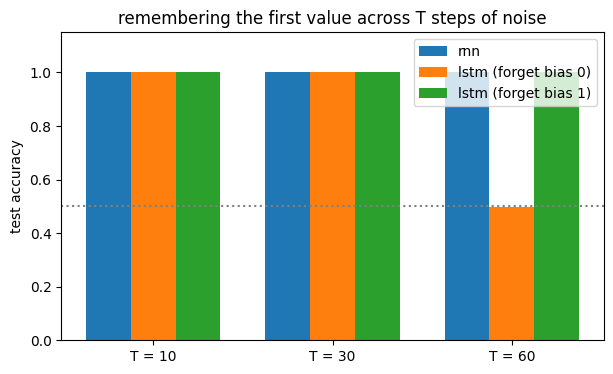

In [12]:
import numpy as np

w = 0.25
xpos = np.arange(len(lengths))
plt.figure(figsize=(7,4))
for j, (name, vals) in enumerate(results.items()):
    plt.bar(xpos + j*w, vals, w, label=name)
plt.xticks(xpos + w, ['T = ' + str(t) for t in lengths])
plt.axhline(0.5, ls=':', c='grey')
plt.ylabel('test accuracy'); plt.legend(); plt.ylim(0,1.15)
plt.title('remembering the first value across T steps of noise')
plt.show()

## what actually happened

not what the textbook says. at T = 60 the **plain RNN solved it** and the LSTM with the default forget bias **failed**, it sat at 50 percent wich is just guessing. the same LSTM with the forget bias set to 1 solved it.

the reason is in notebook 01. the forget gate is `sigmoid(bias + ...)` and with bias 0 it starts at 0.5, so the cell state is halved at every step. after 60 steps that is 0.5^60, the memory is long gone before training even begins. so the LSTM starts worse than an RNN and never recovers.

with bias 1 the gate starts around 0.73, high enough for gradients to flow, and then it learns to push it closer to 1 where it needs to.

so an LSTM is not automatically better than an RNN. it is better **when the forget gate is open**, and pytorch does not open it for you.

## checking that claim directly

In [14]:
for bias in [0.0, 1.0, 2.0]:
    gate = torch.sigmoid(torch.tensor(bias)).item()
    print("forget bias", bias, " gate starts at", round(gate, 3),
          " memory left after 60 steps :", format(gate ** 60, '.2e'))

forget bias 0.0  gate starts at 0.5  memory left after 60 steps : 8.67e-19
forget bias 1.0  gate starts at 0.731  memory left after 60 steps : 6.87e-09
forget bias 2.0  gate starts at 0.881  memory left after 60 steps : 4.93e-04


0.5^60 comes out 8.7e-19, completly gone. bias 1 gives 6.9e-09, still tiny but about ten orders of magnitude bigger, and that is enough gradient at the start for training to push the gate up towards 1 on its own. bias 2 keeps 0.0005.

so the bias does not hold the memory by itself, it only keeps the gradient alive long enough for the network to learn to hold it.

### what i learned

- an LSTM cell is 5 lines, four gates and one memory line, `c = f*c + i*g`
- packing the gates into one `4H` matrix and using `chunk` is a neat trick, one matmul instead of four
- the textbook claim "LSTM fixes long memory" is only half true, the forget gate bias decides it
- initialising the forget bias to 1 is a real thing people do, and now i know why
- i tried T = 100 and 150 also, the results were all over the place at 300 epochs so i left them out instead of showing a random number